### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 5</center>
---

### Overview

The main objective of this exercise is to study histogram processing, which is particularly useful for image enhancement. Depending on the specific method, the information required can usually be extracted *automatically* from the image data, so that it is not necessary to specify any parameters. One of the most common methods in this context is histogram equalization, where the distribution of the gray values in the output image should have a uniform distribution.

The following figure illustrates the idea:

<br />
<center><img src="images/histogram-equilization.png" width="800px" /></center>

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

### <span style="color: RoyalBlue; font-weight: bold;">Task 5.1</span> Histogram Computation and Analysis

As computing histograms is a standard task, many program libraries (for example, Numpy) provide functions for this. Nonetheless, writing a custom function helps to understand the workflow of the program libraries. In this example, an image of pollen particles taken with a scanning electron microscope is considered. The image is available in four variants (pollen-var1.png - pollen-var4.png, shown smaller here for overview):

<img src="images/pollen-var1.png" width="200px"> <img src=images/pollen-var2.png width="200px"> <img src="images/pollen-var3.png" width="200px"> <img src="images/pollen-var4.png" width="200px"><br />

Implement the following tasks:
1. Write a function to compute the histogram of a given grayscale image.
2. Read an image (pollen-var1.png from the folder *images*) as a grayscale image and compute the histogram using this function.
3. Plot the histogram based on your function.
4. Compare the results with the function <a href="https://numpy.org/doc/stable/reference/generated/numpy.histogram.html">`hist` ↗</a> from matplotlib (use <a href="https://numpy.org/doc/stable/reference/generated/numpy.ndarray.flatten.html">`flatten` ↗</a> on the image at first to get the 1D histogram).
5. Characterize the four images (pollen-var1.png - pollen-var4.png from the folder *images*) based on their histograms.


In [2]:
# compute histogram of given image
def compute_histogram(img):
    rows, cols = img.shape # image size
    
    # list to save frequency of each gray value
    hist = np.zeros(256, dtype=np.float64)
    
    for iy in range(rows):
        for jx in range(cols):
            val = img[iy, jx] # get current gray value
            hist[val] += 1
            
    return hist

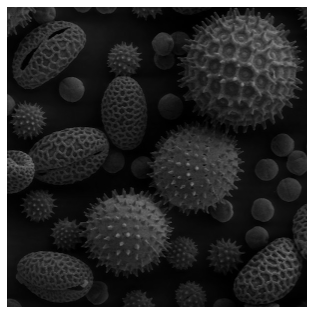

In [3]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/pollen-var1.png', 0)
plot_img_orig(img)

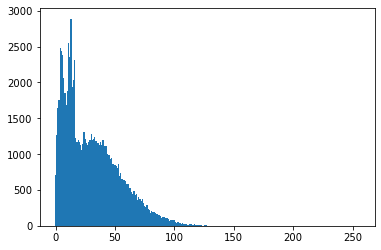

In [4]:
# compute histogram
hist = compute_histogram(img)

# plot the result
val = np.arange(256) # horizontal axis (gray values)
plt.bar(val, hist, 1)
plt.show()

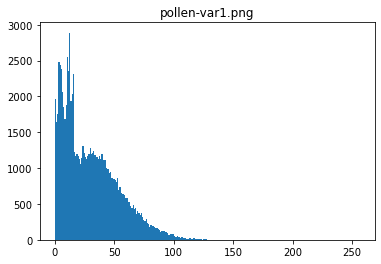

In [5]:
# compare with matplotlib
plt.hist(cv2.imread('images/pollen-var1.png', 0).flatten(), 255, [0, 256])
plt.title('pollen-var1.png')
plt.show()

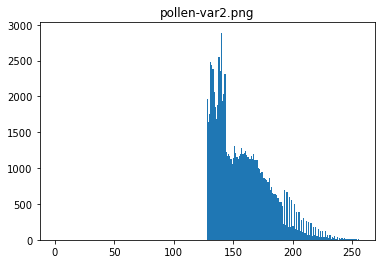

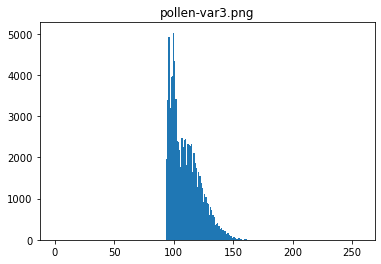

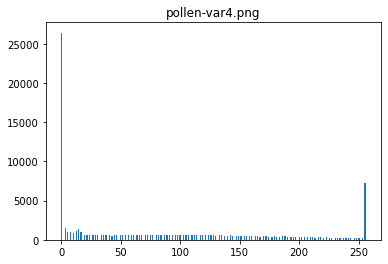

In [6]:
# histograms of the remaining three images
plt.hist(cv2.imread('images/pollen-var2.png', 0).flatten(), 255, [0, 256])
plt.title('pollen-var2.png')
plt.show()

plt.hist(cv2.imread('images/pollen-var3.png', 0).flatten(), 255, [0, 256])
plt.title('pollen-var3.png')
plt.show()

plt.hist(cv2.imread('images/pollen-var4.png', 0).flatten(), 255, [0, 256])
plt.title('pollen-var4.png')
plt.show()

The images can be characterized as follows:

`pollen-var1.png`: dark image.

`pollen-var2.png`: light image.

`pollen-var3.png`: low-contrast image.

`pollen-var4.png`: high-contrast image.

### <span style="color: RoyalBlue; font-weight: bold;">Task 5.2</span> Global Histogram Equalization

Implement / solve the following tasks:

1. Write a function to apply histogram equalization to a given grayscale image.
2. Apply the histogram equalization to the four images (pollen-var1.png - pollen-var4.png from the folder *images*) and plot the results.
3. Compare the histograms of the equalized images with the histograms from the previous task. Are the distributions of the output images uniform?
4. Plot the four transformation functions $T(r_k)$ in one diagram and analyze them with regard to the histograms.
5. What happens when using a checkerboard? Test it (use checkerboard.png from the folder *images*).

In [7]:
# apply histogram equalization to given image
def histogram_equalization(img):
    rows, cols = img.shape # image size
    
    # compute histogram (or use np.histogram)
    hist = compute_histogram(img)
    
    # normalize histogram
    hist_norm = hist / (rows * cols)
    print(sum(hist_norm)) # just for control
    
    # compute transfer function
    tf = np.zeros(256, dtype=np.float64)
    
    for i in range (hist_norm.size):
        tf[i] = 255 * sum(hist_norm[0:i+1]) #cdf ? multiplied with 255 to make pixel values.
        #this loop is a trick to spread the pixel values from 1 to 255
        #Integrator is an average filter, MA filter, or a low pass filter.
    

    # equalization
    res = np.zeros(shape=[rows, cols], dtype=np.uint8) # empty image

    for iy in range(rows):
        for jx in range(cols):
            res[iy, jx] = tf[img[iy, jx]]
    
    # return final result and transfer function
    return res, tf

1.0000000000000004


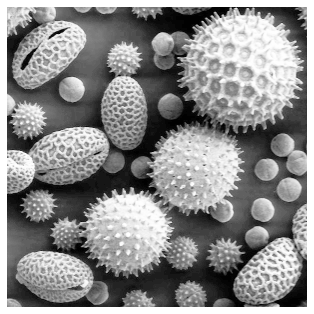

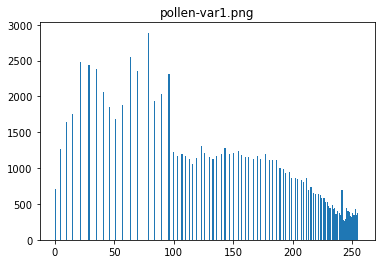

In [8]:
# equalize the four images and plot the results
img = cv2.imread('images/pollen-var1.png', 0)
res1, tf1 = histogram_equalization(img)
plot_img_orig(res1)
plt.hist(res1.flatten(), 255, [0, 256])
plt.title('pollen-var1.png')
plt.show()

0.9999999999999997


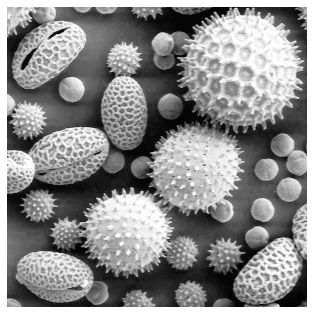

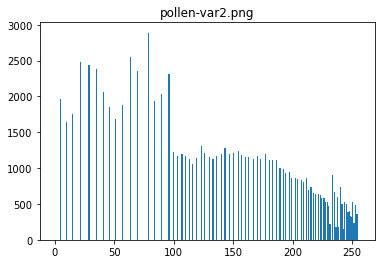

In [9]:
img = cv2.imread('images/pollen-var2.png', 0)
res2, tf2 = histogram_equalization(img)
plot_img_orig(res2)
plt.hist(res2.flatten(), 255, [0, 256])
plt.title('pollen-var2.png')
plt.show()

1.0


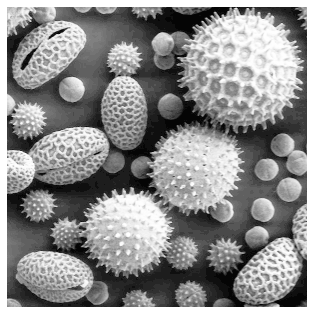

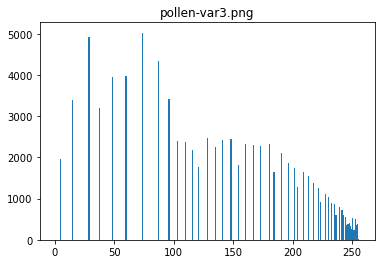

In [10]:
img = cv2.imread('images/pollen-var3.png', 0)
res3, tf3 = histogram_equalization(img)
plot_img_orig(res3)
plt.hist(res3.flatten(), 255, [0, 256]); plt.title('pollen-var3.png'); plt.show()

1.0


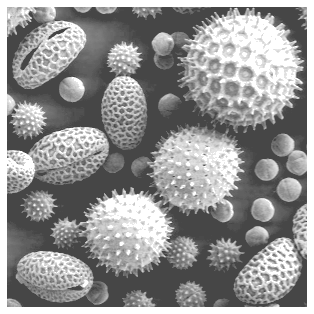

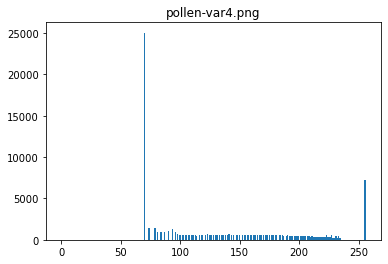

In [11]:
img = cv2.imread('images/pollen-var4.png', 0)
res4, tf4 = histogram_equalization(img)
plot_img_orig(res4)
plt.hist(res4.flatten(), 255, [0, 256]); plt.title('pollen-var4.png'); plt.show()

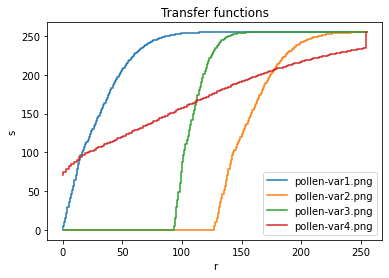

In [12]:
# plot the transfer functions
val = np.arange(256) # horizontal axis (gray values)
plt.step(val, tf1, label='pollen-var1.png')
plt.step(val, tf2, label='pollen-var2.png')
plt.step(val, tf3, label='pollen-var3.png')
plt.step(val, tf4, label='pollen-var4.png')

plt.title("Transfer functions")
plt.xlabel("r")
plt.ylabel("s")

plt.legend()
plt.show()

1.0


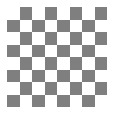

In [13]:
# checkerboard
img = cv2.imread('images/checkerboard-small.png', 0)
res, tf = histogram_equalization(img)
plot_img_orig(res)

The image quality was significantly improved. Nonetheless, the distributions of the output images are not perfectly uniform and they have gaps. This is because each gray value of the input image is only mapped to one specific gray value in the output image. In other words, the distribution is spread while the height of the bins does not change. Furthermore, the histrograms are discrete approximations of probability density functions, while the transformation function has been derived based on continuous functions.

The transformation functions map the input gray values to the output gray values. For example, pollen-var3.png has gray values in range of approx. $[100, 150]$. It can be seen that the transfer function maps this interval to the complete range of $[0, 255]$.

For the checkerboard, the black areas are assigned a higher gray value (they are getting lighter), while the white areas do not change. This is because the mechanics (transfer function) of histogram equalization does not allow to assign gray values of 255 to lower gray values (because the transformation function is the sum of a probability density function so that the sum is 1 there).

### <span style="color: RoyalBlue; font-weight: bold;">Task 5.3</span> Local Histogram Equalization

The global histogram equalization from the previous tasks is suitable for an overall enhancement of images, but often fails to enhance details in small image areas. For this purpose, the histogram equalization can be applied to a local neighborhood of each pixel. At each location, the corresponding transfer function can be applied to the pixel in the center of the neighborhood. In this example, an image with hidden symbols is considered. Furthermore, the image contains some background noise.

Implement / solve the following tasks:

1. Read an image (squares.png from the folder *images*) as a grayscale image and plot it.
2. Apply global histogram equalization to the image and plot the result.
3. Write a function to apply local histogram equalization to a given grayscale image using $N\times N$ windows ($N$ should be odd).
4. Apply this function to the image using $N = 3$, then plot and analyze the results.
5. What happens when using a checkerboard? Test it (use checkerboard-small.png from the folder *images*).

*Note*: When implementing neighborhood operations it is necessary to consider what happens when approaching the border of the image. In this example, the border can just be left out.

In [14]:
# apply local histogram equalization to given image using NxN windows (odd N required)
def local_histogram_equalization(img, n):
    rows, cols = img.shape # image size
    
    # create empty image
    res = np.zeros(shape=[rows, cols], dtype=np.uint8)
    
    # compute offset/ borders that we dont want to process, h=1 if n=3
    h = int(n / 2)
    
    # move from pixel to pixel (border is just left out)
    for iy in range(h, rows-h):
        for jx in range(h, cols-h):
            # get local neighborhood
            nbh = img[iy-h:iy+h+1, jx-h:jx+h+1]
            
            # compute transfer function and equalized neighborhood
            res_he, tf = histogram_equalization(nbh)
            
            # use the transfer function to assign the new gray value
            res[iy, jx] = tf[img[iy, jx]]
            
            # print some status information
        print("row = " + str(iy), end='\r') # current row
            
    # return final result
    return res

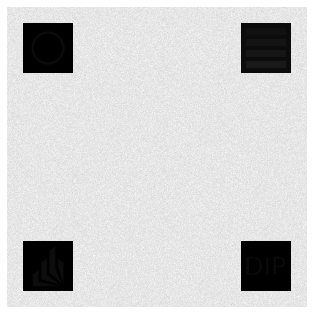

In [15]:
# plot original image
img = cv2.imread('images/squares.png', 0)
plot_img_orig(img)

1.0


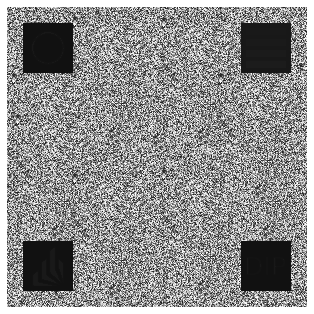

In [16]:
# equalize the four images and plot the results
res_global, tf = histogram_equalization(img)
plot_img_orig(res_global)

1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
0.9999999999999999
0.9999999999999999
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
0.9999999999999999
0.9999999999999999
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
0.9999999999999999
0.9999999999999999
1.0
0.9999999999999999
1.0
1.0
0.9999999999999999
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.00000000000000

1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
0.9999999999999999
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0 = 3
0.9999999999999999
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0


1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
0.9999999999999999
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0 = 6
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
0.9999999999999999
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.9999999999999999
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000

1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
0.9999999999999999
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
0.9999999999999999
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.000

1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
0.9999999999999999
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
0.9999999999999999
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
0.9999999999999999
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0000

...

1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
0.9999999999999999
1.0
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
0.9999999999999999
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0000

1.0000000000000002
1.0
1.0000000000000002
0.9999999999999999
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
0.9999999999999999
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
0.9999999999999999
1.0
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.000000000

1.0
1.0
1.0
1.0
1.0
0.9999999999999999
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
0.9999999999999999
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0

1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
0.9999999999999999
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0
0.9999999999999999
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0
1.0

1.0
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0
0.9999999999999999
1.0000000000000002
1.0000000000000002
1.0
1.0000000000000002
1.0
1.0000000000000002
0.9999999999999999
1.0
1.0000000000000002
1.0
1.0
0.9999999999999999
1.0
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.00000

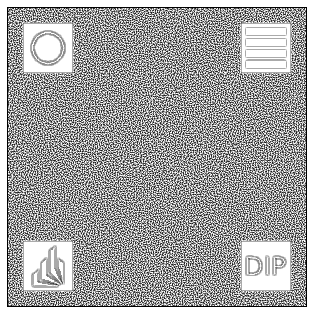

True

In [17]:
# local histogram equalization
res_local = local_histogram_equalization(img, 3)
plot_img_orig(res_local)
cv2.imwrite('output/local.png', res_local)

In [18]:
print("row = " + str(298), end='\r') #carrige return, 
print("row = " + str(299))           # if printing 1.0000... values, check previous function definition

row = 298
row = 299


1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0 = 1
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0 = 2
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0 = 21
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0 = 22
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0 = 23
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0 = 43
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0 = 44
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0 = 64
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0 = 65
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0 = 84
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0 = 85
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0 = 86
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1

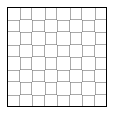

In [19]:
# checkerboard
img = cv2.imread('images/checkerboard-small.png', 0)
res_local = local_histogram_equalization(img, 3)
plot_img_orig(res_local)

The global histogram equalization is not suitable to clearly identify the hidden symbols inside the boxes. The local method works much better, but mainly highlights the edges and considerably amplifies the noise. Furthermore, the method is quite slow (but it can be accelerated by reusing data, because only one row or column changes when moving from pixel to pixel). A better method for such problems is a local enhancement using histogram statistics.

The checkerboard consists of homogeneous areas (only one gray value) so that the equalization does only have an effect on the edges. 